In [1]:
1.25**4

2.44140625

In [2]:
(1 + 1 / 12)**12

2.613035290224676

In [3]:
(1+1/10000)**10000

2.7181459268249255

In [4]:
import numpy as np

In [5]:
np.e

2.718281828459045

In [6]:
(1+1/10000)**10000**(-10000)

1.0

In [7]:
np.e**(1+1/10000)

2.7185536702337534

In [8]:
import pandas as pd
import risk_kit as rk
%load_ext autoreload
%autoreload 2
    

In [9]:
def inst_to_ann(r):
    """
    Convert short rate to annualized rate
    """
    return np.expm1(r)

def ann_to_inst(r):
    """
    Convert annulized rate to short rate
    """
    return np.log1p(r)

$$ dr_{t}=a(b-r_{t})\,dt+\sigma {\sqrt  {r_{t}}}\,dW_{t} $$

In [10]:
def cir(n_years = 10, n_scenarios = 1, a = 0.05, b = 0.03, sigma = 0.05, steps_per_year = 12, r_0 = None):
    """
    Implements the CIR model for interest rates
    """
    if r_0 is None: r_0 = b
    r_0 = ann_to_inst(r_0)
    dt = 1 / steps_per_year
    
    num_steps = int(n_years * steps_per_year) + 1
    shock = np.random.normal(0, scale = np.sqrt(dt), size = (num_steps, n_scenarios))
    rates = np.empty_like(shock)
    rates[0] = r_0
    for step in range(1, num_steps):
        r_t = rates[step - 1]
        d_r_t = a * (b - r_t) * dt + sigma * np.sqrt(r_t) * shock[step]
        rates[step] = abs(r_t + d_r_t) # rarely turn negative, but just to be cautious and avoid the rounding error scenerio
    return pd.DataFrame(data = inst_to_ann(rates), index = range(num_steps))

<Axes: >

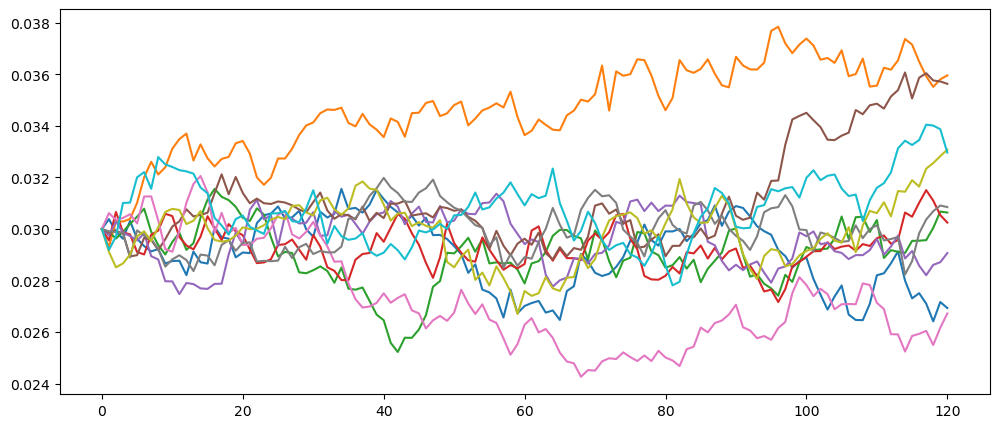

In [14]:
cir(n_scenarios = 10, sigma = 0.01).plot(figsize = (12 , 5), legend = False)

In [15]:
import ipywidgets as widgets
from IPython.display import display

In [19]:
def show_cir(n_years = 10, n_scenarios = 10, a = 0.05, b = 0.03, sigma = 0.01, steps_per_year = 12):
    cir(n_years = n_years, n_scenarios = n_scenarios, a = a, b = b, sigma = sigma, steps_per_year = steps_per_year).plot(figsize = (12 , 5), legend = False)
cir_controls = widgets.interactive(show_cir, 
                                   n_years=widgets.IntSlider(min=1, max=100, step=1, value=50), 
                                   n_scenarios=widgets.IntSlider(min=1, max=100, step=1, value=50), 
                                   a=(0., +.5, .01),
                                   b=(0., +.5, .01),
                                   sigma=(0, .30, .01),
                                   steps_per_year=(0, 250, 1)
)
display(cir_controls)

interactive(children=(IntSlider(value=50, description='n_years', min=1), IntSlider(value=50, description='n_sc…

$$P(t,T)=A(t,T)e^{-B(t,T)r_{t}}\!$$

where

$$ A(t,T)=\left({\frac  {2h e^{(a+h)\tau/2}}{2h+(a+h)(e^{\tau h}-1)}}\right)^{{2ab/\sigma ^{2}}} $$
and
$$ B(t,T)={\frac  {2(e^{\tau h}-1)}{2h+(a+h)(e^{\tau h}-1)}} $$
and
$$ h={\sqrt  {a^{2}+2\sigma ^{2}}} $$
and
$$ \tau = T-t $$

In [20]:
import math
def cir(n_years = 10, n_scenarios=1, a=0.05, b=0.03, sigma=0.05, steps_per_year=12, r_0=None):
    """
    Generate random interest rate evolution over time using the CIR model
    b and r_0 are assumed to be the annualized rates, not the short rate
    and the returned values are the annualized rates as well
    """
    if r_0 is None: r_0 = b 
    r_0 = ann_to_inst(r_0)
    dt = 1/steps_per_year
    num_steps = int(n_years*steps_per_year) + 1 # because n_years might be a float
    
    shock = np.random.normal(0, scale=np.sqrt(dt), size=(num_steps, n_scenarios))
    rates = np.empty_like(shock)
    rates[0] = r_0

    ## For Price Generation
    h = math.sqrt(a**2 + 2*sigma**2)
    prices = np.empty_like(shock)
    ####

    def price(ttm, r):
        _A = ((2*h*math.exp((h+a)*ttm/2))/(2*h+(h+a)*(math.exp(h*ttm)-1)))**(2*a*b/sigma**2)
        _B = (2*(math.exp(h*ttm)-1))/(2*h + (h+a)*(math.exp(h*ttm)-1))
        _P = _A*np.exp(-_B*r)
        return _P
    prices[0] = price(n_years, r_0)
    ####
    
    for step in range(1, num_steps):
        r_t = rates[step-1]
        d_r_t = a*(b-r_t)*dt + sigma*np.sqrt(r_t)*shock[step]
        rates[step] = abs(r_t + d_r_t)
        # generate prices at time t as well ...
        prices[step] = price(n_years-step*dt, rates[step])

    rates = pd.DataFrame(data=inst_to_ann(rates), index=range(num_steps))
    ### for prices
    prices = pd.DataFrame(data=prices, index=range(num_steps))
    ###
    return rates, prices


In [21]:
def show_cir_prices(r_0=0.03, a=0.5, b=0.03, sigma=0.05, n_scenarios=5):
    cir(r_0=r_0, a=a, b=b, sigma=sigma, n_scenarios=n_scenarios)[1].plot(legend=False, figsize=(12,5))

controls = widgets.interactive(show_cir_prices,
                              r_0 = (0, .15, .01),
                              a = (0, 1, .1),
                               b = (0, .15, .01),
                               sigma= (0, .1, .01),
                               n_scenarios = (1, 100))
display(controls)

interactive(children=(FloatSlider(value=0.03, description='r_0', max=0.15, step=0.01), FloatSlider(value=0.5, …

In [23]:
a_0 = .75 # cash on hand, in millions
rates, bond_prices = cir(n_years = 10, r_0 = .03, b = 0.03, n_scenarios = 10)
liabilities = bond_prices
zcbond_10 = pd.Series(data = [1], index = [10])
zc_0 = rk.pv(zcbond_10, r = 0.03) # price of the zero-coupon bond today
zc_0

np.float64(0.7440939148967249)

In [24]:
zcbond_10

10    1
dtype: int64

In [25]:
n_bonds = a_0 / zc_0 
av_zc_bond = n_bonds * bond_prices # asset value
av_cash = a_0 * (rates / 12 + 1).cumprod()


<Axes: >

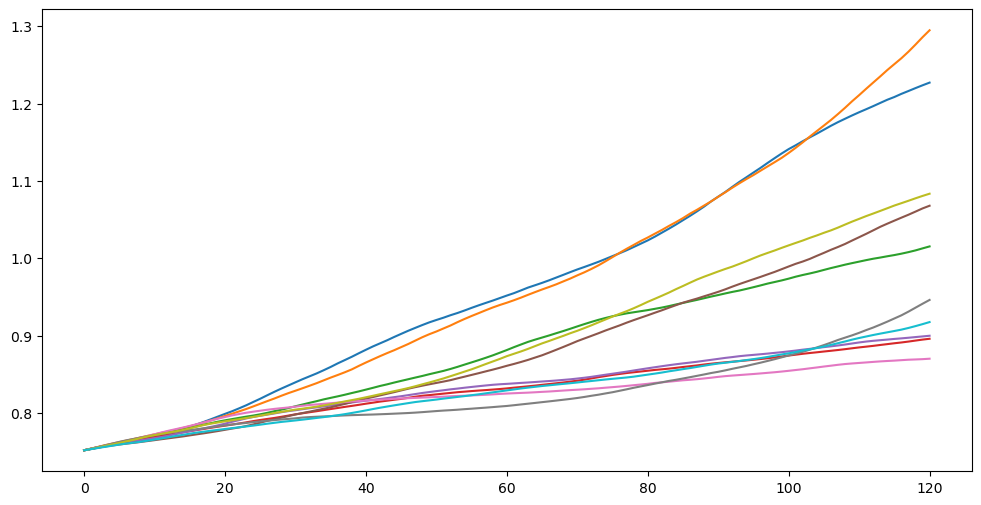

In [26]:
av_cash.plot(legend = False, figsize = (12, 6))

<Axes: >

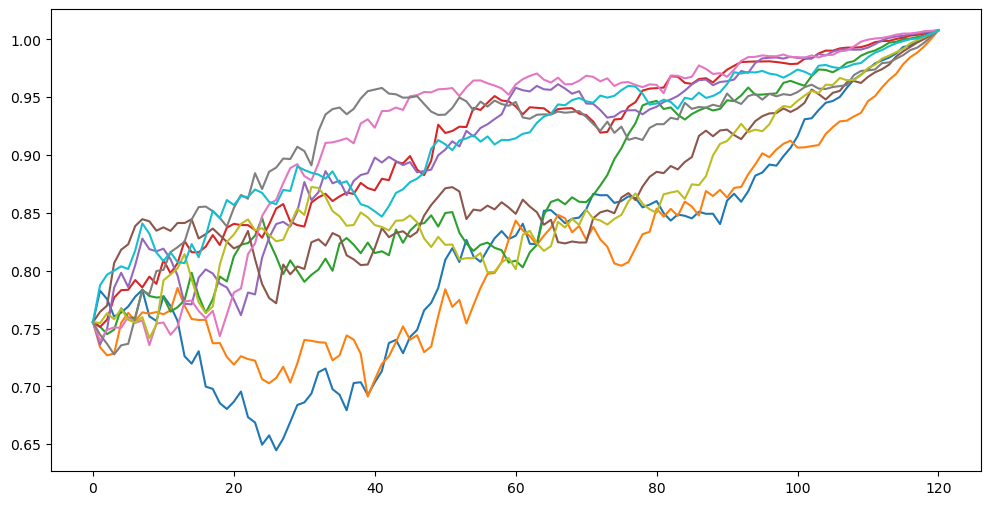

In [27]:
av_zc_bond.plot(legend = False, figsize = (12, 6))

<Axes: title={'center': 'Returns of Funding Ratio with Cash (10 scenarios)'}>

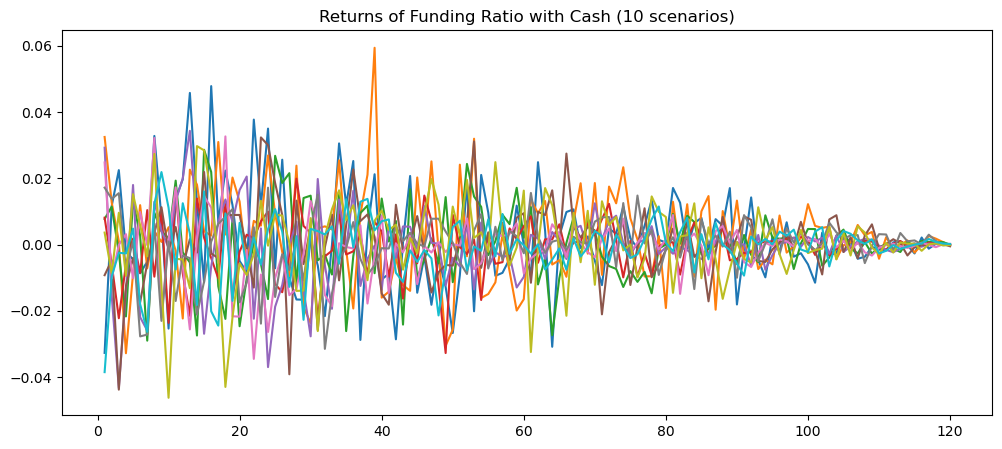

In [28]:
(av_cash / liabilities).pct_change().plot(title = "Returns of Funding Ratio with Cash (10 scenarios)", legend = False, figsize = (12, 5))

<Axes: title={'center': 'Returns of Funding Ratio with Zero-Coupon Bond (10 scenarios)'}>

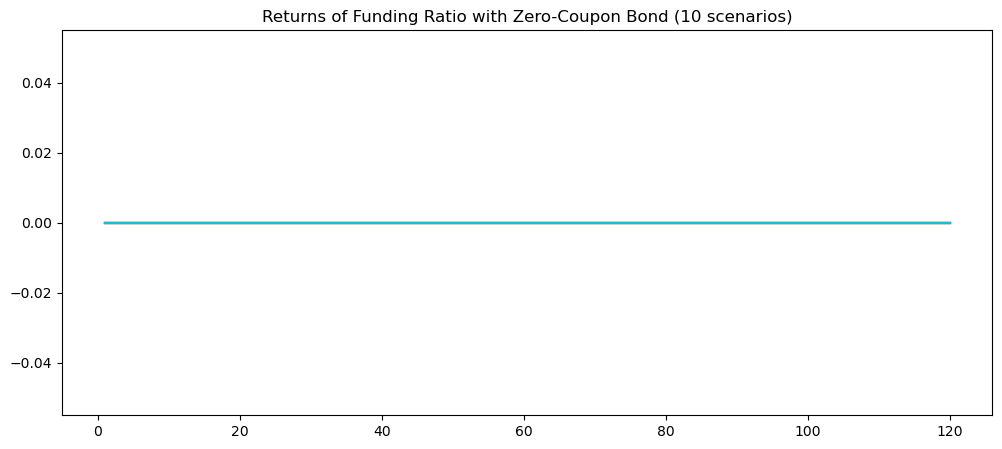

In [31]:
(av_zc_bond / liabilities).pct_change().plot(title = "Returns of Funding Ratio with Zero-Coupon Bond (10 scenarios)", legend = False, figsize = (12, 5))

In [45]:
a_0 = 0.5
rates, bond_prices = cir(n_years = 10, r_0 = .03, b = 0.03, n_scenarios = 10000)
liabilities = bond_prices
zcbond_10 = pd.Series(data = [1], index = [10])
zc_0 = rk.pv(zcbond_10, r = 0.03) # price of the zero-coupon bond today
n_bonds = a_0 / zc_0 
av_zc_bond = n_bonds * bond_prices # asset value
av_cash = a_0 * (rates / 12 + 1).cumprod()

In [46]:
tfr_cash = av_cash.iloc[-1] / liabilities.iloc[-1] #terminal funding ratio
tfr_zc_bonds = av_zc_bond.iloc[-1] / liabilities.iloc[-1]

<Axes: >

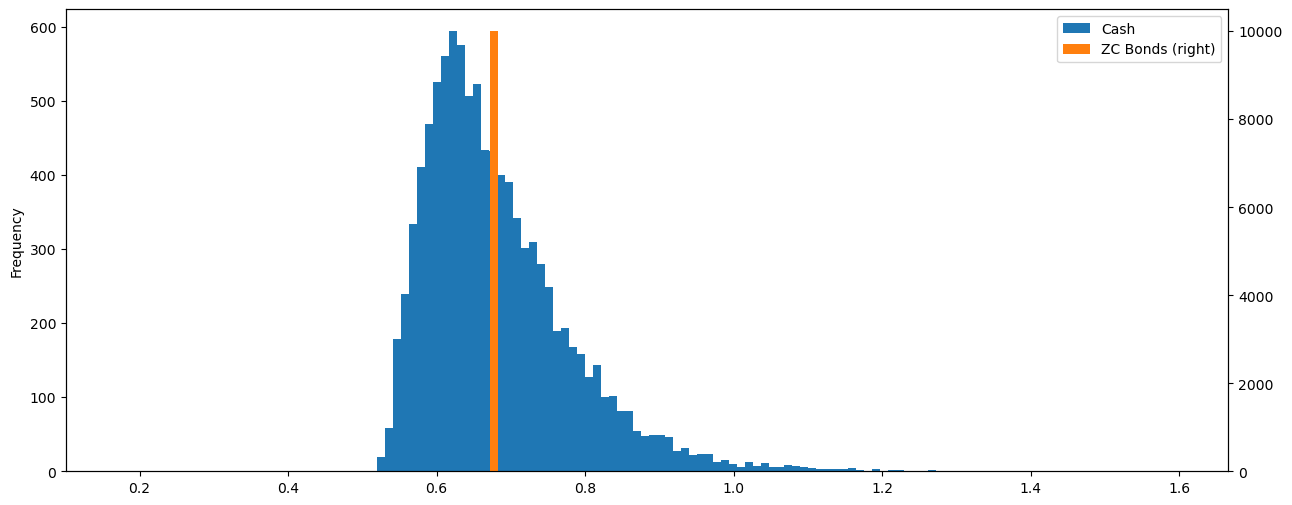

In [47]:
ax = tfr_cash.plot.hist(label = 'Cash', figsize = (15, 6), bins = 100, legend = True)
tfr_zc_bonds.plot.hist(ax = ax, label = 'ZC Bonds', bins = 100, legend = True, secondary_y = True)